# Demo 02: Equilibrium & Stability

How do you know a biological system has reached equilibrium? This demo builds
the same zynol↔brevix↔corthan chemistry from Demo 01 (using the shared helper
this time), runs it longer, and uses `check_stability` to programmatically
detect when concentrations stop changing.

In [1]:
import sys
from pathlib import Path

# Ensure alienbio is importable
_root = Path(".").resolve().parent.parent / "src"
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
_demos = Path(".").resolve().parent
if str(_demos) not in sys.path:
    sys.path.insert(0, str(_demos))

%matplotlib inline


## Build the System

`_shared.make_homeostatic_system` creates the same 3-molecule zynol↔brevix↔corthan
chemistry from Demo 01 (see that notebook for the full construction code). Here
we use a different seed and run for 1000 steps — long enough to be confident
about convergence.

In [2]:
from _shared import make_homeostatic_system

system = make_homeostatic_system(seed=99)
timeline = system.run(1000)

print(f"Steps: {len(timeline)}")
print(f"Final: { {m: round(system.state[m], 3) for m in system.state} }")


Steps: 1001
Final: {'zynol': 1.433, 'brevix': 2.86, 'corthan': 5.706}


## Stability Check

`check_stability` computes the variance of each molecule's concentration over
a trailing **window** (here, the last 100 steps). If the maximum variance
across all molecules is below the **threshold**, the system is considered
stable.

The returned `StabilityResult` has:
- `stable` — `True` if all variances are below threshold
- `max_variance` — the largest variance seen across molecules

In [3]:
from alienbio.bio import check_stability

result = check_stability(timeline, window=100, threshold=1e-4)
print(f"Stable: {result.stable}")
print(f"Max variance: {result.max_variance:.6f}")


Stable: True
Max variance: 0.000005


## Trajectories

With seed=99 the initial transient is slightly different from Demo 01, but
the system still converges to the same equilibrium point (determined by the
rate constants, not the seed).

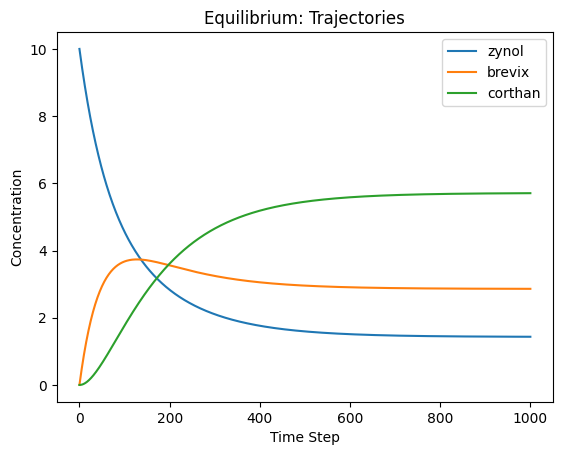

In [4]:
from alienbio.viz import concentration_trajectory, equilibrium_convergence

concentration_trajectory(timeline, title="Equilibrium: Trajectories");


## Convergence Analysis

The convergence plot shows per-molecule rolling variance over the timeline.
By step ~400 the variance has dropped well below the 1e-4 threshold, matching
the `check_stability` result above.

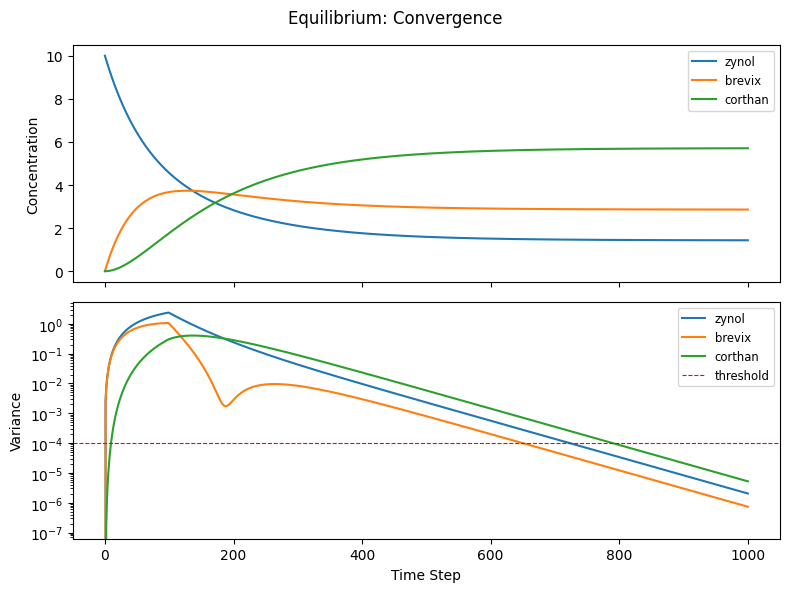

In [5]:
equilibrium_convergence(timeline, window=100, title="Equilibrium: Convergence");